# Modelado de la Interacción entre Redes Regulatorias y el Microambiente

**Sección 2.9 — Modelos Continuos Mecanísticos**

Este cuaderno explora cómo acoplar dos escalas temporales en biología de sistemas:

- **Procesos rápidos** (minutos–horas): Redes bioquímicas que regulan decisiones fenotípicas.
- **Procesos lentos** (días–semanas): Procesos tisulares que regulan el microambiente.

**Objetivo didáctico:** Entender cómo la *separación de escalas temporales* (QSSA) permite reducir sistemas complejos de EDOs a modelos de baja dimensión, y cómo el análisis de puntos focales revela cuatro comportamientos cualitativos clínicos: homeostasis, inflamación crónica, biestabilidad y oscilaciones.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100


## 1. El problema: dos escalas temporales acopladas

Consideremos dos variables:

- $S(t)$: una condición **microambiental** que cambia **lentamente** (días–semanas).
- $X(t)$: el **fenotipo celular** que cambia **rápidamente** (minutos–horas).

Sus dinámicas están **acopladas**:

$$\dot{S} = F(S, X), \qquad \dot{X} = G(S, X)$$

**Pregunta central:** ¿Cómo modelar este sistema sin resolver simultáneamente dos escalas temporales muy distintas?

La respuesta es la **Hipótesis de Cuasi-Estado-Estacionario (QSSA)**: como $X$ evoluciona mucho más rápido que $S$, podemos asumir que $X$ siempre está en su equilibrio instantáneo $\dot{X} = 0$.

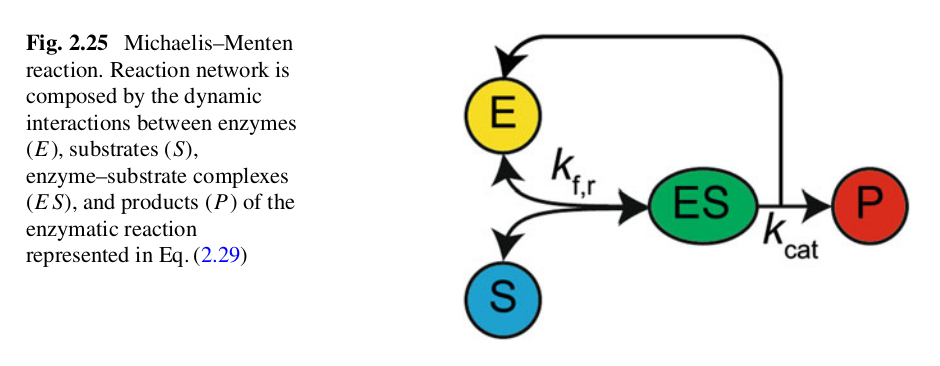

## 2. Hipótesis de Cuasi-Estado-Estacionario (QSSA)

**Suposición:** $X(t)$ evoluciona en una escala $t$ mucho más rápida que $S(t)$ en su escala $\tau$ ($t \ll \tau$).

Esto implica:
$$\dot{X} = G(S, X) = 0 \quad\Longrightarrow\quad X_{\text{ss}}(S)$$

Es decir, $X$ se vuelve una función **algebraica** de $S$. El sistema completo se reduce a:

$$\boxed{\;\dot{S} = F\big(\tau,\, X_{\text{ss}}(S)\big)\;}$$

**Interpretación biológica:** El fenotipo responde *instantáneamente* a las condiciones del microambiente, mientras que el microambiente evoluciona lentamente según la mezcla de fenotipos presentes en el tejido.

> **Remark 2.36:** Como $F$ depende explícitamente de $X_{\text{ss}}(S)$, la dinámica del parámetro de bifurcación $S$ refleja la **proporción de fenotipos** en el tejido.

In [ ]:
display(Markdown("### Demostración numérica de QSSA"))

def demo_qssa(eps=0.05, tau_max=20):
    """
    Sistema acoplado con dos escalas: 
      eps * dX/dτ = -X + S      (rápido)
      dS/dτ      = -0.5*S + 0.1*X (lento)
    eps → 0 produce separación de escalas.
    """
    def sys(y, tau, eps):
        X, S = y
        dX = (-X + S) / eps
        dS = -0.5*S + 0.1*X
        return [dX, dS]
    
    tau = np.linspace(0, tau_max, 2000)
    sol = odeint(sys, [0.0, 1.0], tau, args=(eps,))
    X, S = sol[:,0], sol[:,1]
    
    # Solución QSSA: X_ss(S) = S
    X_qssa = S  # porque X_ss = S
    
    fig, axes = plt.subplots(1, 2, figsize=(13,4))
    
    axes[0].plot(tau, X, label='X(t) — completa', color='#3b82f6', lw=2.5)
    axes[0].plot(tau, X_qssa, '--', label='$X_{ss}(S)=S$ — QSSA', color='#f59e0b', lw=2)
    axes[0].set_xlabel('τ (escala lenta)')
    axes[0].set_ylabel('X (fenotipo)')
    axes[0].set_title(f'Fenotipo X con ε={eps:.3f}')
    axes[0].legend()
    
    axes[1].plot(tau, S, color='#22a06b', lw=2.5, label='S(t) — microambiente')
    axes[1].set_xlabel('τ (escala lenta)')
    axes[1].set_ylabel('S (microambiente)')
    axes[1].set_title('Microambiente S')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

widgets.interact(demo_qssa,
                 eps=widgets.FloatSlider(value=0.05, min=0.005, max=1.0, step=0.005,
                                         description='ε:'),
                 tau_max=widgets.FloatSlider(value=20, min=5, max=50, step=1,
                                             description='τ_max:'))

### Demostración numérica de QSSA

interactive(children=(FloatSlider(value=0.05, description='ε:', max=1.0, min=0.005, step=0.005), FloatSlider(v…

<function __main__.demo_qssa(eps=0.05, tau_max=20)>

**Interpretación:** al reducir ε, la curva azul (dinámica completa) se pega a la curva naranja (QSSA). Esto valida numéricamente la hipótesis. Cuando ε≈1, la separación de escalas desaparece y QSSA deja de ser válida.

## 3. El sistema de Briggs-Haldane (Michaelis-Menten)

Ejemplo clásico de QSSA. La red de reacción es:

$$E + S \;\underset{k_r}{\overset{k_f}{\rightleftharpoons}}\; ES \;\overset{k_{cat}}{\longrightarrow}\; E + P$$

Las EDOs completas son:

$$
\begin{aligned}
\frac{d[E]}{dt} &= -k_f[E][S] + k_r[ES] + k_{cat}[ES] \\
\frac{d[S]}{dt} &= -k_f[E][S] + k_r[ES] \\
\frac{d[ES]}{dt} &= k_f[E][S] - k_r[ES] - k_{cat}[ES] \\
\frac{d[P]}{dt} &= k_{cat}[ES]
\end{aligned}
$$

**Conservación de enzima:** $\;\dfrac{d[E]}{dt} + \dfrac{d[ES]}{dt} = 0 \;\Rightarrow\; [E] + [ES] = [E]_0$.

**QSSA sobre el complejo $[ES]$:** $\dfrac{d[ES]}{dt} = 0 \;\Rightarrow\; [ES]_{ss} = \dfrac{k_f[E]_0[S]}{(k_r + k_{cat}) + k_f[S]}$.

Definiendo $K_M = \dfrac{k_r + k_{cat}}{k_f}$:

$$\boxed{\;\frac{d[P]}{dt} = k_{cat}\frac{[E]_0[S]}{K_M + [S]}\;}$$

**Resultado clave:** un sistema 4D se reduce a **1 sola EDO**.

In [13]:
display(Markdown("### Briggs-Haldane: EDOs completas vs. QSSA"))

def briggs_haldane_full(kf=1.0, kr=0.5, kcat=0.5, E0=10.0, S0=100.0, t_max=20):
    def sys(y, t):
        E, S, ES, P = y
        dE  = -kf*E*S + kr*ES + kcat*ES
        dS  = -kf*E*S + kr*ES
        dES =  kf*E*S - kr*ES - kcat*ES
        dP  =  kcat*ES
        return [dE, dS, dES, dP]
    
    t = np.linspace(0, t_max, 1000)
    sol = odeint(sys, [E0, S0, 0.0, 0.0], t)
    return t, sol

def briggs_haldane_qssa(kf=1.0, kr=0.5, kcat=0.5, E0=10.0, S0=100.0, t_max=20):
    KM = (kr + kcat) / kf
    def dP_dt(P, t):
        # Para obtener S(t) usamos balance: S0 - P - ES (aprox: ES pequeña)
        S = max(S0 - P, 1e-9)
        return kcat * E0 * S / (KM + S)
    t = np.linspace(0, t_max, 1000)
    P = odeint(dP_dt, 0.0, t)
    return t, P

def plot_bh(kf, kr, kcat, E0, S0):
    t, sol_full = briggs_haldane_full(kf, kr, kcat, E0, S0)
    t2, P_qssa = briggs_haldane_qssa(kf, kr, kcat, E0, S0)
    E, S, ES, P = sol_full.T
    
    fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
    
    axes[0].plot(t, E,  label='E',  color='#f59e0b', lw=2)
    axes[0].plot(t, S,  label='S',  color='#3b82f6', lw=2)
    axes[0].plot(t, ES, label='ES', color='#22a06b', lw=2)
    axes[0].plot(t, P,  label='P',  color='#dc2626', lw=2)
    axes[0].set_xlabel('t'); axes[0].set_ylabel('[ ]')
    axes[0].set_title('Sistema completo (4D)')
    axes[0].legend()
    
    axes[1].plot(t, P, label='P — completa', color='#dc2626', lw=2.5)
    axes[1].plot(t2, P_qssa, '--', label='P — QSSA (1D)', color='#16324f', lw=2)
    axes[1].set_xlabel('t'); axes[1].set_ylabel('[P]')
    axes[1].set_title('Reducción QSSA vs. solución exacta')
    axes[1].legend()
    
    plt.tight_layout(); plt.show()

widgets.interact(plot_bh,
                 kf=widgets.FloatSlider(value=1.0, min=0.1, max=5, step=0.1, description='$k_f$:'),
                 kr=widgets.FloatSlider(value=0.5, min=0.1, max=5, step=0.1, description='$k_r$:'),
                 kcat=widgets.FloatSlider(value=0.5, min=0.1, max=5, step=0.1, description='$k_{cat}$:'),
                 E0=widgets.FloatSlider(value=10, min=1, max=50, step=1, description='$[E]_0$:'),
                 S0=widgets.FloatSlider(value=100, min=10, max=300, step=10, description='$[S]_0$:'))

### Briggs-Haldane: EDOs completas vs. QSSA

interactive(children=(FloatSlider(value=1.0, description='$k_f$:', max=5.0, min=0.1), FloatSlider(value=0.5, d…

<function __main__.plot_bh(kf, kr, kcat, E0, S0)>

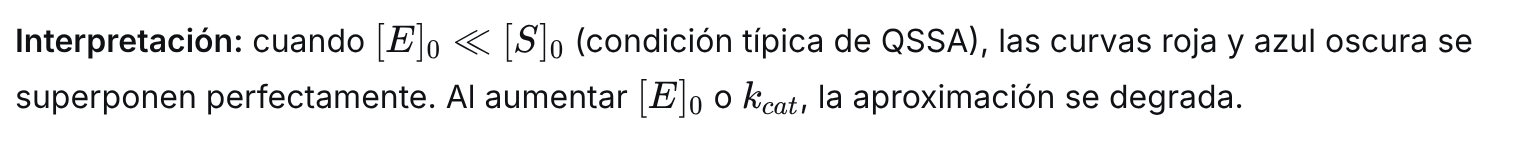

## 4. Dinámica biestable y aproximación PWA (Piecewise-Affine)

En un sistema **biestable**, el fenotipo $E$ puede estar en dos estados estables según el estímulo $S$:

- $S < S^-$: solo existe el estado **bajo** ($E_{low}$).
- $S > S^+$: solo existe el estado **alto** ($E_{high}$).
- $S \in [S^-, S^+]$: **histéresis** — el estado depende del pasado.

### Aproximación PWA

En vez de resolver el sistema completo (que requeriría un diagrama de bifurcación costoso), describimos la respuesta con una **función afín a trozos** (Ec. 2.31):

$$
E(\tau) = \begin{cases}
E_{low} & \text{si } S(\tau) < S^- \;\text{ o }\;\{S\in[S^-,S^+] \text{ y } E_{prev}=E_{low}\}\\
E_{high} & \text{si } S(\tau) > S^+ \;\text{ o }\;\{S\in[S^-,S^+] \text{ y } E_{prev}=E_{high}\}
\end{cases}
$$

**Idea clave:** la memoria del sistema se codifica en el valor previo de $E$.

In [ ]:
display(Markdown("### Respuesta PWA biestable: Curva de histéresis PWA"))

def pwa_response(S_vals, S_minus=0.8, S_plus=1.2, E_low=0.0, E_high=1.0, E_init='low'):
    """Recorre S de ida y vuelta, devolviendo E con histéresis."""
    E_prev = E_low if E_init == 'low' else E_high
    E_vals = []
    for S in S_vals:
        if S < S_minus:
            E_prev = E_low
        elif S > S_plus:
            E_prev = E_high
        # else: mantener E_prev (histéresis)
        E_vals.append(E_prev)
    return np.array(E_vals)

def plot_pwa(S_minus, S_plus, E_init):
    S_up = np.linspace(0, 2, 400)
    S_down = S_up[::-1]
    
    E_up = pwa_response(S_up, S_minus, S_plus, E_init='low')
    E_down = pwa_response(S_down, S_minus, S_plus, E_init='high')
    
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(S_up, E_up, color='#dc2626', lw=2.5, label='S creciente (desde estado bajo)')
    ax.plot(S_down, E_down, color='#3b82f6', lw=2.5, label='S decreciente (desde estado alto)')
    ax.axvline(S_minus, color='gray', ls=':', alpha=0.6)
    ax.axvline(S_plus,  color='gray', ls=':', alpha=0.6)
    ax.text(S_minus, 1.05, '$S^-$', ha='center', color='gray')
    ax.text(S_plus,  1.05, '$S^+$', ha='center', color='gray')
    ax.fill_betweenx([-0.1, 1.1], S_minus, S_plus, color='#fef3c7', alpha=0.4, zorder=0)
    ax.set_xlabel('S (estímulo)')
    ax.set_ylabel('E (efector)')
    ax.set_title('Respuesta PWA biestable — Histéresis')
    ax.set_xlim(0, 2); ax.set_ylim(-0.1, 1.15)
    ax.legend(loc='center right')
    plt.tight_layout(); plt.show()

widgets.interact(plot_pwa,
                 S_minus=widgets.FloatSlider(value=0.8, min=0.1, max=1.0, step=0.05, description='$S^-$:'),
                 S_plus=widgets.FloatSlider(value=1.2, min=1.0, max=1.9, step=0.05, description='$S^+$:'),
                 E_init=widgets.Dropdown(options=['low','high'], value='low', description='E inicial:'))

### Respuesta PWA biestable: Curva de histéresis PWA

interactive(children=(FloatSlider(value=0.8, description='$S^-$:', max=1.0, min=0.1, step=0.05), FloatSlider(v…

<function __main__.plot_pwa(S_minus, S_plus, E_init)>

## 5. El sistema híbrido acoplado (Ecs. 2.31 y 2.32)

Ahora acoplamos las dos escalas: el estímulo lento $S(\tau)$ **depende del fenotipo** $E(\tau)$:

$$
\dot{S}(\tau) = \begin{cases}
F_{low}(S)  & \text{si } E(\tau) = E_{low} \\
F_{high}(S) & \text{si } E(\tau) = E_{high}
\end{cases}
$$

**Modelo lineal simple** (didáctico):

$$F_{low}(S) = k(S_{ss}^{low} - S), \qquad F_{high}(S) = k(S_{ss}^{high} - S)$$

donde $S_{ss}^{low}$ y $S_{ss}^{high}$ son los **puntos focales** del sistema lento.

**Comportamiento a largo plazo:** depende de la posición relativa de $S_{ss}^{low}$ y $S_{ss}^{high}$ respecto a los umbrales $S^-$ y $S^+$.

In [15]:
display(Markdown("### Simulación del sistema híbrido PWA + dinámica lenta"))

def simulate_hybrid(S_ss_low, S_ss_high, S_minus=0.8, S_plus=1.2,
                    E_low=0.0, E_high=1.0, k=0.5,
                    S0=0.5, E0='low', tau_max=60, dtau=0.01):
    tau = np.arange(0, tau_max, dtau)
    S_arr = np.zeros_like(tau)
    E_arr = np.zeros_like(tau)
    
    S = S0
    E_prev = E_low if E0 == 'low' else E_high
    
    for i, t in enumerate(tau):
        # Regla PWA para E (histéresis)
        if S < S_minus:
            E_prev = E_low
        elif S > S_plus:
            E_prev = E_high
        # else: mantener E_prev
        
        E_arr[i] = E_prev
        S_arr[i] = S
        
        # Dinámica lenta de S
        if E_prev == E_low:
            dS = k * (S_ss_low - S)
        else:
            dS = k * (S_ss_high - S)
        S += dS * dtau
    
    return tau, S_arr, E_arr

def plot_hybrid(S_ss_low, S_ss_high, S0, E0):
    S_minus, S_plus = 0.8, 1.2
    tau, S, E = simulate_hybrid(S_ss_low, S_ss_high, S0=S0, E0=E0)
    
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                              gridspec_kw={'height_ratios':[2,1]})
    
    # Panel S vs tau (con umbrales y puntos focales)
    axes[0].plot(tau, S, color='#22a06b', lw=2.5, label='S(τ)')
    axes[0].axhline(S_minus, color='gray', ls=':', alpha=0.7, label='$S^-$')
    axes[0].axhline(S_plus,  color='gray', ls=':', alpha=0.7, label='$S^+$')
    axes[0].axhline(S_ss_low,  color='#3b82f6', ls='--', alpha=0.7, label='$S_{ss}^{low}$')
    axes[0].axhline(S_ss_high, color='#dc2626', ls='--', alpha=0.7, label='$S_{ss}^{high}$')
    axes[0].set_ylabel('S')
    axes[0].set_title('Microambiente S(τ)')
    axes[0].legend(loc='best', ncol=2, fontsize=9)
    
    # Panel E vs tau
    axes[1].plot(tau, E, color='#16324f', lw=2.5)
    axes[1].set_xlabel('τ (tiempo lento)')
    axes[1].set_ylabel('E')
    axes[1].set_title('Fenotipo E(τ)')
    axes[1].set_ylim(-0.1, 1.1)
    
    plt.tight_layout(); plt.show()

widgets.interact(plot_hybrid,
                 S_ss_low=widgets.FloatSlider(value=0.5, min=0.0, max=2.0, step=0.05, description='$S_{ss}^{low}$:'),
                 S_ss_high=widgets.FloatSlider(value=1.5, min=0.0, max=2.0, step=0.05, description='$S_{ss}^{high}$:'),
                 S0=widgets.FloatSlider(value=0.5, min=0.0, max=2.0, step=0.05, description='$S_0$:'),
                 E0=widgets.Dropdown(options=['low','high'], value='low', description='E inicial:'))

### Simulación del sistema híbrido PWA + dinámica lenta

interactive(children=(FloatSlider(value=0.5, description='$S_{ss}^{low}$:', max=2.0, step=0.05), FloatSlider(v…

<function __main__.plot_hybrid(S_ss_low, S_ss_high, S0, E0)>

## 6. Análisis de puntos focales: los 4 comportamientos cualitativos

La posición de los **puntos focales** $S_{ss}^{low}$ y $S_{ss}^{high}$ respecto a los umbrales $S^-$ y $S^+$ determina el comportamiento a largo plazo del sistema híbrido (Fig. 2.26 del texto):

| # | Comportamiento | Condición | Significado clínico |
|---|---|---|---|
| (i) | **Homeostasis** | $S_{ss}^{low} \le S^+$ y $S_{ss}^{high} < S^-$ | Estado de reposo (bajo) globalmente estable |
| (ii) | **Inflamación crónica** | $S_{ss}^{low} > S^+$ y $S_{ss}^{high} \ge S^-$ | Estado excitado (alto) globalmente estable |
| (iii) | **Biestabilidad** | $S_{ss}^{low} \le S^+$ pero $S_{ss}^{high} \ge S^-$ | Coexistencia de dos atractores |
| (iv) | **Oscilaciones** | $S_{ss}^{low} > S^+$ y $S_{ss}^{high} < S^-$ | Ciclo límite (relojes biológicos) |

**Idea biológica:** pequeños cambios en los puntos focales (por mutaciones o factores tisulares) pueden **conmutar** el sistema entre fenotipos sanos y patológicos.

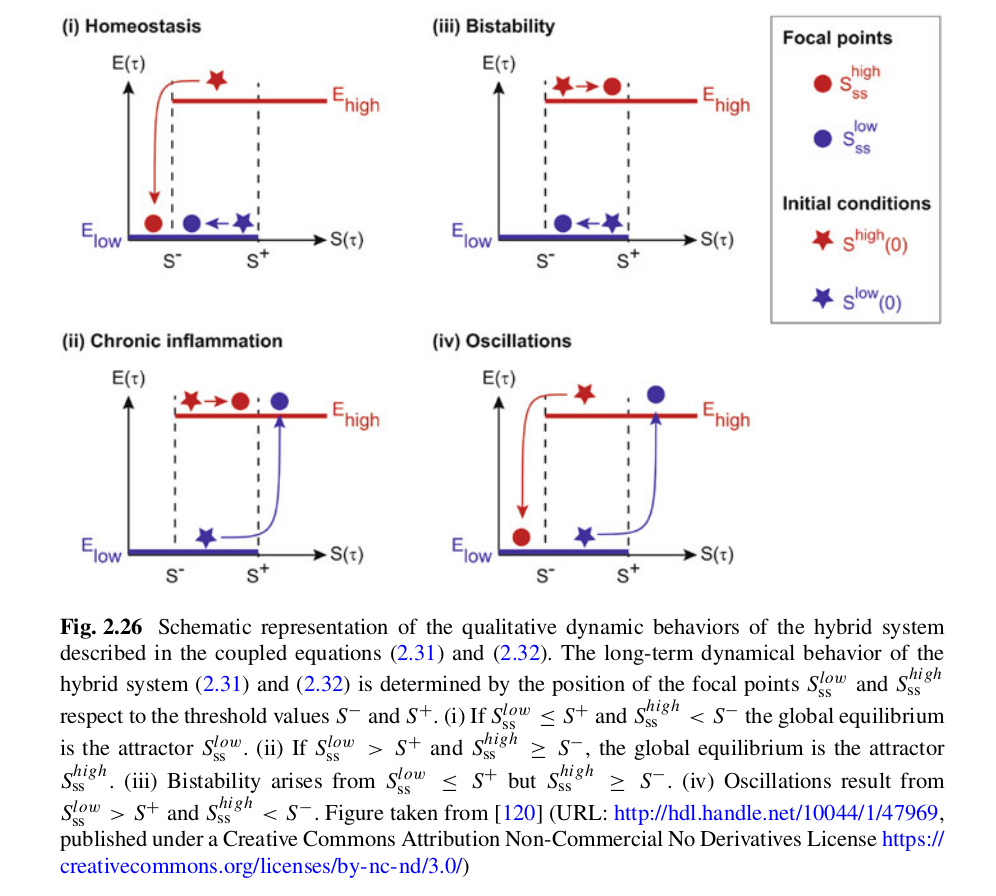

In [19]:
display(Markdown("### Los cuatro comportamientos cualitativos (Fig. 2.26)"))

SCENARIOS = {
    '(i) Homeostasis':        {'S_ss_low': 0.5, 'S_ss_high': 0.3},
    '(ii) Inflamación crónica':{'S_ss_low': 1.5, 'S_ss_high': 1.0},
    '(iii) Biestabilidad':    {'S_ss_low': 0.5, 'S_ss_high': 1.0},
    '(iv) Oscilaciones':      {'S_ss_low': 1.5, 'S_ss_high': 0.3},
}

S_MINUS, S_PLUS = 0.8, 1.2

def plot_scenario(escenario, S0, E0):
    params = SCENARIOS[escenario]
    tau, S, E = simulate_hybrid(params['S_ss_low'], params['S_ss_high'],
                                 S_minus=S_MINUS, S_plus=S_PLUS,
                                 S0=S0, E0=E0, tau_max=80)
    
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                              gridspec_kw={'height_ratios':[2,1]})
    
    axes[0].plot(tau, S, color='#22a06b', lw=2.5, label='S(τ)')
    axes[0].axhline(S_MINUS, color='gray', ls=':', alpha=0.7, label='$S^-$')
    axes[0].axhline(S_PLUS,  color='gray', ls=':', alpha=0.7, label='$S^+$')
    axes[0].axhline(params['S_ss_low'],  color='#3b82f6', ls='--', alpha=0.7,
                    label=f"$S_{{ss}}^{{low}}={params['S_ss_low']}$")
    axes[0].axhline(params['S_ss_high'], color='#dc2626', ls='--', alpha=0.7,
                    label=f"$S_{{ss}}^{{high}}={params['S_ss_high']}$")
    axes[0].set_ylabel('S'); axes[0].set_title(f'Microambiente — {escenario}')
    axes[0].legend(loc='best', ncol=2, fontsize=9)
    
    axes[1].plot(tau, E, color='#16324f', lw=2.5)
    axes[1].set_xlabel('τ'); axes[1].set_ylabel('E')
    axes[1].set_title('Fenotipo E(τ)')
    axes[1].set_ylim(-0.1, 1.1)
    
    plt.tight_layout(); plt.show()

widgets.interact(plot_scenario,
                 escenario=widgets.Dropdown(options=list(SCENARIOS.keys()),
                                            value='(iii) Biestabilidad',
                                            description='Escenario:'),
                 S0=widgets.FloatSlider(value=0.5, min=0.0, max=2.0, step=0.05, description='$S_0$:'),
                 E0=widgets.Dropdown(options=['low','high'], value='low', description='E inicial:'))

### Los cuatro comportamientos cualitativos (Fig. 2.26)

interactive(children=(Dropdown(description='Escenario:', index=2, options=('(i) Homeostasis', '(ii) Inflamació…

<function __main__.plot_scenario(escenario, S0, E0)>

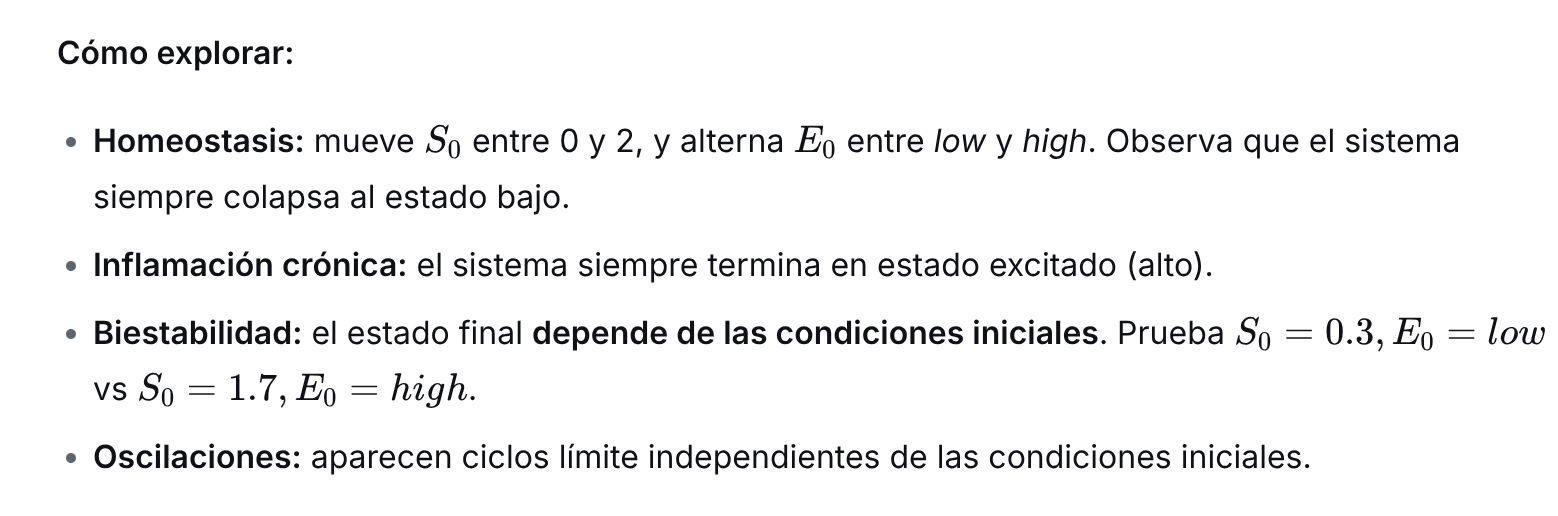

# Retrato de fase general — Espacio de parámetros

### Mapa de comportamientos en el espacio $(S_{ss}^{low}, S_{ss}^{high})$

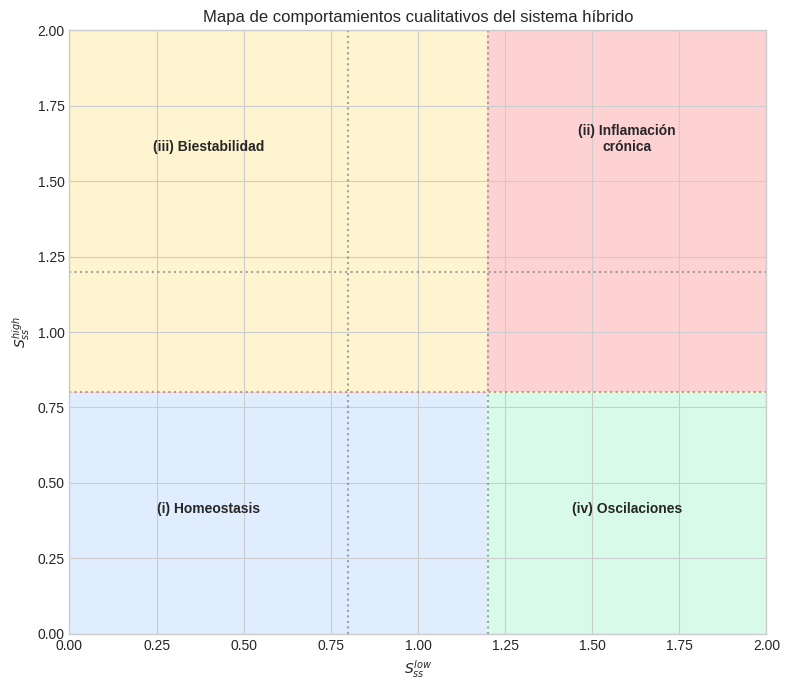

In [17]:
display(Markdown("### Mapa de comportamientos en el espacio $(S_{ss}^{low}, S_{ss}^{high})$"))

def mapa_comportamientos():
    S_minus, S_plus = 0.8, 1.2
    grid = np.linspace(0, 2, 300)
    Sl, Sh = np.meshgrid(grid, grid)
    
    # Clasificación de cada punto
    behavior = np.zeros_like(Sl)
    # 1: homeostasis, 2: crónica, 3: biestable, 4: oscilaciones
    homeostasis = (Sl <= S_plus) & (Sh < S_minus)
    cronica     = (Sl >  S_plus) & (Sh >= S_minus)
    biestable   = (Sl <= S_plus) & (Sh >= S_minus)
    oscil       = (Sl >  S_plus) & (Sh <  S_minus)
    
    behavior[homeostasis] = 1
    behavior[cronica]     = 2
    behavior[biestable]   = 3
    behavior[oscil]       = 4
    
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#dbeafe', '#fecaca', '#fef3c7', '#d1fae5'])
    
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(behavior, origin='lower', extent=[0,2,0,2], cmap=cmap, aspect='auto', alpha=0.85)
    ax.axvline(S_minus, color='gray', ls=':', alpha=0.7)
    ax.axvline(S_plus,  color='gray', ls=':', alpha=0.7)
    ax.axhline(S_minus, color='gray', ls=':', alpha=0.7)
    ax.axhline(S_plus,  color='gray', ls=':', alpha=0.7)
    
    ax.text(0.4, 0.4, '(i) Homeostasis', ha='center', fontsize=10, weight='bold')
    ax.text(1.6, 1.6, '(ii) Inflamación\ncrónica', ha='center', fontsize=10, weight='bold')
    ax.text(0.4, 1.6, '(iii) Biestabilidad', ha='center', fontsize=10, weight='bold')
    ax.text(1.6, 0.4, '(iv) Oscilaciones', ha='center', fontsize=10, weight='bold')
    
    ax.set_xlabel('$S_{ss}^{low}$')
    ax.set_ylabel('$S_{ss}^{high}$')
    ax.set_title('Mapa de comportamientos cualitativos del sistema híbrido')
    plt.tight_layout(); plt.show()

mapa_comportamientos()

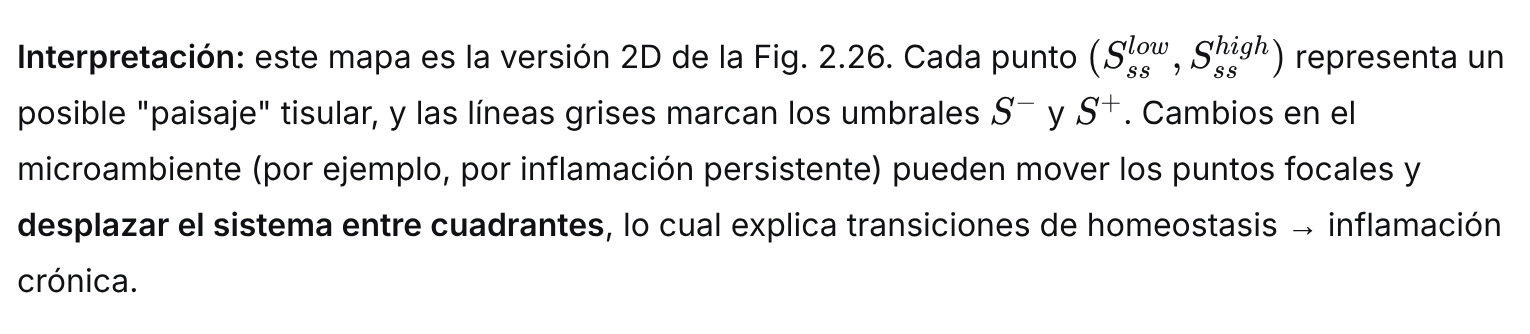

## 7. Conclusiones y observaciones finales

1. **QSSA** permite colapsar sistemas multi-escala en modelos algebraicos de baja dimensión. Es la herramienta matemática que conecta lo **rápido** (biología molecular) con lo **lento** (fisiología tisular).

2. **Briggs-Haldane** es el ejemplo canónico: un sistema 4D se reduce a **una sola EDO** sin pérdida cualitativa importante.

3. La **aproximación PWA** evita resolver diagramas de bifurcación completos. Codifica la respuesta biestable con 4 reglas algebraicas simples y una memoria discreta.

4. El **análisis de puntos focales** revela que la posición de $S_{ss}^{low}$ y $S_{ss}^{high}$ frente a $S^-$ y $S^+$ determina cuatro comportamientos clínicamente relevantes:
   - **Homeostasis** (i): el sistema se estabiliza bajo.
   - **Inflamación crónica** (ii): el sistema se estabiliza alto.
   - **Biestabilidad** (iii): coexisten dos atractores, hay memoria.
   - **Oscilaciones** (iv): ciclo límite, ritmos biológicos.

5. **Relevancia clínica:** enfermedades degenerativas crónicas frecuentemente emergen de **aberraciones en la interacción fenotipo-microambiente**. Este marco permite identificar dónde perturbar un sistema para restaurar la homeostasis.

### Sugerencias para el estudiante
- Modifica los sliders de la sección 5 y 13 para cruzar los umbrales.
- Intenta implementar $F_{low}$ y $F_{high}$ no lineales (por ejemplo, Hill) y verifica si las cuatro clases cualitativas se preservan.
- ¿Qué pasa si los umbrales $S^-$ y $S^+$ son iguales? (Se pierde la histéresis y el sistema se vuelve un interruptor puro).